# Road Accident Hotspot & Safe Route Finder
**Course:** Artificial Intelligence  
**Project Type:** Civic AI Project  
**Dataset:** US Accidents (2016–2023) Kaggle  

## Task: Data Loading & Cleaning

In [ ]:
import sys
from types import ModuleType
import pandas as pd
import numpy as np
import warnings

# Fix for broken PyArrow DLL
class Dummy(object): pass
pa = ModuleType('pyarrow')
pa.Table = pa.RecordBatch = pa.Array = pa.ChunkedArray = Dummy
pa.__version__ = '99.0.0'
pa.__path__ = []
sys.modules['pyarrow'] = pa
sys.modules['pyarrow.compute'] = ModuleType('pyarrow.compute')
sys.modules['pyarrow.lib'] = ModuleType('pyarrow.lib')

warnings.filterwarnings('ignore')

print("Loading data (optimized sample)...")
df = pd.read_csv("US_Accidents_March23.csv", 
                 usecols=['ID', 'Severity', 'Start_Lat', 'Start_Lng', 'Street', 'City', 'Distance(mi)'],
                 nrows=2000000)

df = df[df['City'] == 'Miami'].copy()
df = df.dropna().reset_index(drop=True)
df['Severity'] = df['Severity'].astype(int)

df = df[df['Start_Lat'].between(25.5, 26.0)]
df = df[df['Start_Lng'].between(-80.5, -80.0)]
print(f"Miami sample size: {len(df)} records")

df = df.sort_values('Severity', ascending=False).reset_index(drop=True)
print(f"\nTop 10 severe accidents in sample:")
print(df.head(10))


Loading data (optimized sample)...
Miami sample size: 21293 records

Top 10 severe accidents in sample:
          ID  Severity  Start_Lat  Start_Lng  Distance(mi)       Street   City
0  A-1465085         4  25.844481 -80.207092          1.75       I-95 S  Miami
1  A-1409387         4  25.910852 -80.210060          4.30       I-95 S  Miami
2  A-1433876         4  25.882227 -80.209389          1.37  NW 117th St  Miami
3  A-1903074         4  25.927702 -80.206787          0.92       I-95 S  Miami
4  A-1608373         4  25.964170 -80.165855          3.30       I-95 S  Miami
5  A-1903082         4  25.931492 -80.204422          2.06       I-95 S  Miami
6  A-1595702         4  25.852249 -80.208138          1.07       I-95 S  Miami
7   A-145455         4  25.812199 -80.205856          0.00       I-95 N  Miami
8   A-138276         4  25.848932 -80.207596          0.00   NW 81st St  Miami
9   A-137487         4  25.812199 -80.205856          0.00       I-95 N  Miami



### Task: Graph Construction

In [2]:
import networkx as nx

street_data = df.groupby('Street').agg(
    accident_count=('ID', 'count'),
    avg_lat=('Start_Lat', 'mean'),
    avg_lng=('Start_Lng', 'mean')
).reset_index()

street_data = street_data[street_data['accident_count'] >= 1].head(200).reset_index(drop=True)

G = nx.Graph()

def calculate_distance(lat1, lon1, lat2, lon2):
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2) * 111

for index, row in street_data.iterrows():
    G.add_node(row['Street'], pos=(row['avg_lng'], row['avg_lat']), risk=row['accident_count'])
    
for i, r1 in street_data.iterrows():
    for j, r2 in street_data.iterrows():
        if i < j:
            d = calculate_distance(r1['avg_lat'], r1['avg_lng'], r2['avg_lat'], r2['avg_lng'])
            if d <= 8.0:
                risk_weight = round((r1['accident_count'] + r2['accident_count']) / 2, 2)
                G.add_edge(r1['Street'], r2['Street'], distance=round(d, 2), risk=risk_weight)

print(f"Complex Network Built Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Complex Network Built Nodes: 200, Edges: 4938



### Task: Dijkstra Safest & Fastest Route

In [3]:
source = 'Caribbean Blvd'
target = 'NE 3rd Ct'

safest_path = nx.dijkstra_path(G, source, target, weight='risk')
safest_risk = nx.dijkstra_path_length(G, source, target, weight='risk')
safest_dist = sum(G[safest_path[i]][safest_path[i+1]]['distance'] for i in range(len(safest_path)-1))

fastest_path = nx.dijkstra_path(G, source, target, weight='distance')
fastest_dist = nx.dijkstra_path_length(G, source, target, weight='distance')
fastest_risk = sum(G[fastest_path[i]][fastest_path[i+1]]['risk'] for i in range(len(fastest_path)-1))

print("FASTEST ROUTE (Dangerous but Short)")
print(" -> ".join(fastest_path))
print(f"Distance: {fastest_dist:.2f} km  |  Risk Score: {fastest_risk:.1f}")
print()
print("SAFEST ROUTE (Secure but longer)")
print(" -> ".join(safest_path))
print(f"Distance: {safest_dist:.2f} km  |  Risk Score: {safest_risk:.1f}")
print()
if fastest_risk > 0:
    reduction = ((fastest_risk - safest_risk) / fastest_risk) * 100
    extra_km = safest_dist - fastest_dist
    print(f"RESULT: Safest route adds {extra_km:.2f} km but reduces accident risk by {reduction:.1f}%")

FASTEST ROUTE (Dangerous but Short)
Caribbean Blvd -> Busway -> Killian Pkwy -> County Hwy-913 -> Coral Way -> Curtiss Pkwy -> Hialeah Dr -> Gratigny Pkwy -> FL-826 W -> NE 3rd Ct
Distance: 47.15 km  |  Risk Score: 42.5

SAFEST ROUTE (Secure but longer)
Caribbean Blvd -> Dunbar Dr -> FL-94 -> County Hwy-913 -> Florida Blvd -> Apache St -> Broad Manor Rd -> 10B -> NE 3rd Ct
Distance: 49.26 km  |  Risk Score: 12.5

RESULT: Safest route adds 2.11 km but reduces accident risk by 70.6%



### Task: Alternative Route Generation (Alternate Safe Routes)

In [4]:
def find_alternate_routes(graph, source, target, k=3, weight='risk'):
    """
    Finds multiple alternate routes using Yen's K-Shortest Paths logic.
    This guarantees that we find the absolute safest paths in descending order.
    """
    path_gen = nx.shortest_simple_paths(graph, source, target, weight=weight)
    
    all_paths = []
    for path in path_gen:
        all_paths.append(path)
        if len(all_paths) >= k:
            break
            
    return all_paths[1:]

alternate_routes = find_alternate_routes(G, source, target, k=3, weight='risk')

print("ALTERNATE ROUTES:")
for i, p in enumerate(alternate_routes, 1):
    r = sum(G[p[j]][p[j+1]]['risk'] for j in range(len(p)-1))
    d = sum(G[p[j]][p[j+1]]['distance'] for j in range(len(p)-1))
    print(f"Alternate Route {i}: {' -> '.join(p)}")
    print(f"Total Risk: {r:.1f} | Total Distance: {d:.2f} km\n")

ALTERNATE ROUTES:
Alternate Route 1: Caribbean Blvd -> Jefferson St -> FL-94 -> County Hwy-913 -> Florida Blvd -> Apache St -> Broad Manor Rd -> 10B -> NE 3rd Ct
Total Risk: 12.5 | Total Distance: 49.34 km

Alternate Route 2: Caribbean Blvd -> Dunbar Dr -> FL-94 -> County Hwy-913 -> Granada Blvd -> Beacom Blvd -> 6A -> 10B -> NE 3rd Ct
Total Risk: 12.5 | Total Distance: 52.33 km




### Task: BFS Hotspot Detection

In [5]:
from collections import deque

risk_threshold = street_data['accident_count'].quantile(0.75)

def bfs_find_hotspots(graph, start_node, max_hops, threshold):
    visited = {start_node: 0}
    queue = deque([(start_node, 0)])
    hotspots = []

    while queue:
        current, hops = queue.popleft()
        if hops >= max_hops:
            continue
        for neighbor in graph.neighbors(current):
            if neighbor not in visited:
                visited[neighbor] = hops + 1
                queue.append((neighbor, hops + 1))
                if graph.nodes[neighbor]['risk'] >= threshold:
                    hotspots.append((neighbor, graph.nodes[neighbor]['risk'], hops + 1))

    return hotspots

start_node = source
hotspots = bfs_find_hotspots(G, start_node, max_hops=4, threshold=risk_threshold)
hotspots = sorted(hotspots, key=lambda x: -x[1])

print(f"Risk threshold (75th percentile): {risk_threshold:.0f} accidents")
print(f"High-risk zones found within 4 hops from '{start_node}':")
print()
for name, risk, hop in hotspots:
    print(f"  {name}  |  Accidents: {risk:.0f}  |  Hops away: {hop}")

Risk threshold (75th percentile): 12 accidents
High-risk zones found within 4 hops from 'Caribbean Blvd':

  Dolphin Expy E  |  Accidents: 674  |  Hops away: 4
  Florida's Tpke N  |  Accidents: 534  |  Hops away: 2
  Florida's Tpke S  |  Accidents: 518  |  Hops away: 3
  Dolphin Expy W  |  Accidents: 310  |  Hops away: 4
  Bird Rd  |  Accidents: 164  |  Hops away: 3
  N Kendall Dr  |  Accidents: 128  |  Hops away: 2
  Florida's Tpke  |  Accidents: 114  |  Hops away: 3
  FL-821 N  |  Accidents: 76  |  Hops away: 2
  FL-821 S  |  Accidents: 58  |  Hops away: 2
  FL-836 W  |  Accidents: 56  |  Hops away: 4
  FL-836 E  |  Accidents: 49  |  Hops away: 4
  Don Shula Expy S  |  Accidents: 38  |  Hops away: 1
  Grand Canal Dr  |  Accidents: 37  |  Hops away: 4
  Milam Dairy Rd  |  Accidents: 30  |  Hops away: 4
  FL-874 S  |  Accidents: 23  |  Hops away: 2
  Miller Dr  |  Accidents: 17  |  Hops away: 3
  Killian Pkwy  |  Accidents: 15  |  Hops away: 2
  Don Shula Expy N  |  Accidents: 12  |  H


### Task: Visualization & Final Summary

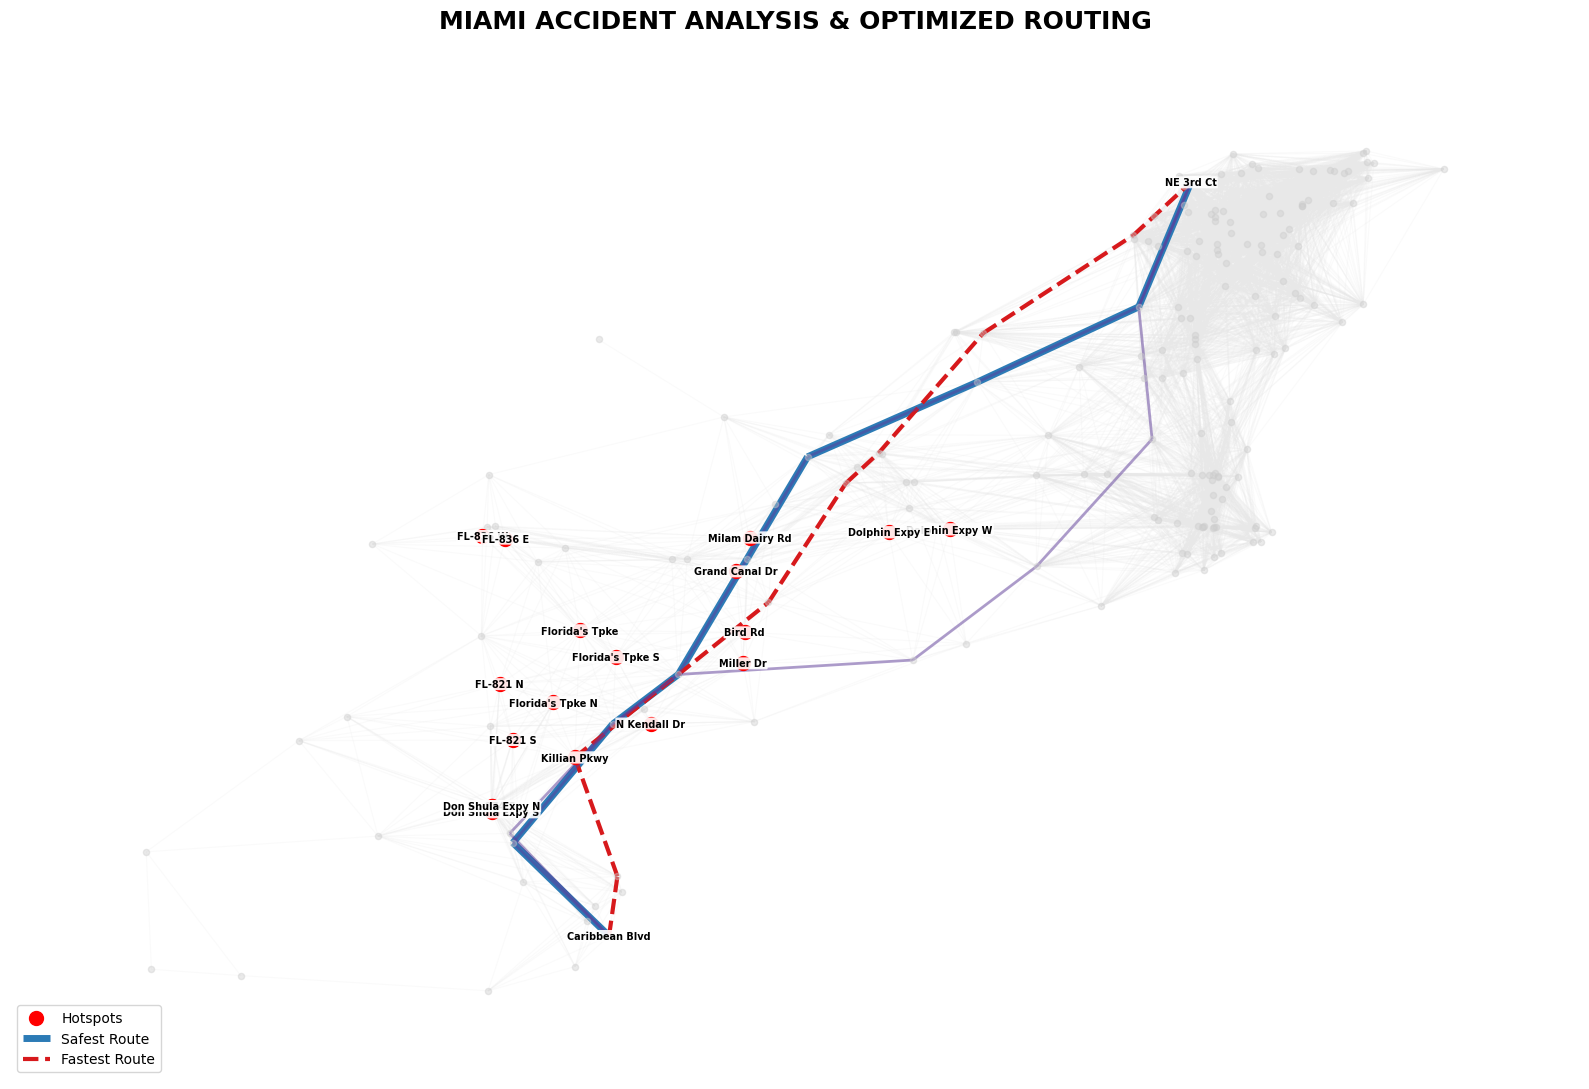

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 11))
pos = nx.get_node_attributes(G, 'pos')

nx.draw_networkx_nodes(G, pos, node_size=20, node_color='#cccccc', alpha=0.4)
nx.draw_networkx_edges(G, pos, width=0.8, edge_color='#e8e8e8', alpha=0.2)

h_list = [n for n, r, h in hotspots]
nx.draw_networkx_nodes(G, pos, nodelist=h_list, node_size=100, node_color='red', node_shape='o', label='Hotspots')

s_edges = list(zip(safest_path, safest_path[1:]))
f_edges = list(zip(fastest_path, fastest_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=s_edges, width=5, edge_color='#2c7bb6', label='Safest Route')
nx.draw_networkx_edges(G, pos, edgelist=f_edges, width=3, edge_color='#d7191c', label='Fastest Route', style='dashed')

for i, p in enumerate(alternate_routes):
    p_edges = list(zip(p, p[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=p_edges, width=2, edge_color='#5e3c99', alpha=0.5)

main_pts = set([source, target] + h_list)
label_subset = {node: node.strip() for node in main_pts}

nx.draw_networkx_labels(G, pos, labels=label_subset, font_size=7, font_weight='bold',
                        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.1'))

plt.title("MIAMI ACCIDENT ANALYSIS & OPTIMIZED ROUTING", fontsize=18, pad=25, fontweight='bold')
plt.legend(loc='lower left', frameon=True, fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.savefig("route_map.png", dpi=300, bbox_inches='tight')
plt.show()

---
# PHASE 3 — Machine Learning Additions
---

## Section 1: K-Means Accident Clustering (Unsupervised ML)


Feature matrix shape: (200, 3)
Features: avg_lat, avg_lng, accident_count (all normalised to mean=0, std=1)


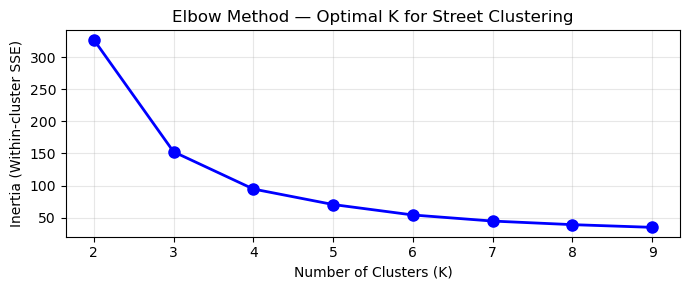

Choose K at the 'elbow' — where inertia stops dropping sharply.


In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

# Prepare feature matrix from Phase 2 street_data
features = street_data[['avg_lat', 'avg_lng', 'accident_count']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print(f"Feature matrix shape: {X_scaled.shape}")
print("Features: avg_lat, avg_lng, accident_count (all normalised to mean=0, std=1)")

# Elbow Method
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 3))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.title('Elbow Method — Optimal K for Street Clustering')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()
print("Choose K at the 'elbow' — where inertia stops dropping sharply.")

In [8]:
# Fit K-Means with optimal K
OPTIMAL_K = 5
n_clusters = OPTIMAL_K
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
street_data['cluster'] = km_final.fit_predict(X_scaled)

# Rank clusters by mean accident count
cluster_risk = street_data.groupby('cluster')['accident_count'].mean().sort_values(ascending=False)
danger_cluster = cluster_risk.index[0]
medium_clusters = list(cluster_risk.index[1:3])

print("Cluster Risk Ranking:")
for rank, (cid, risk) in enumerate(cluster_risk.items(), 1):
    tag = " << DANGER ZONE" if rank == 1 else (" << MODERATE" if rank <= 3 else "")
    print(f"  Rank {rank} | Cluster {cid} | Mean Accidents: {risk:.1f}{tag}")

# Inject cluster labels into graph
cluster_map = dict(zip(street_data['Street'], street_data['cluster']))
for node in G.nodes():
    if node in cluster_map:
        G.nodes[node]['cluster'] = cluster_map[node]
    else:
        G.nodes[node]['cluster'] = -1
print(f"\nCluster labels injected into graph. Danger cluster ID: {danger_cluster}")
print(f"Streets in danger cluster: {(street_data['cluster'] == danger_cluster).sum()}")

Cluster Risk Ranking:
  Rank 1 | Cluster 3 | Mean Accidents: 2316.0 << DANGER ZONE
  Rank 2 | Cluster 4 | Mean Accidents: 75.8 << MODERATE
  Rank 3 | Cluster 2 | Mean Accidents: 31.3 << MODERATE
  Rank 4 | Cluster 0 | Mean Accidents: 8.6
  Rank 5 | Cluster 1 | Mean Accidents: 8.6

Cluster labels injected into graph. Danger cluster ID: 3
Streets in danger cluster: 2


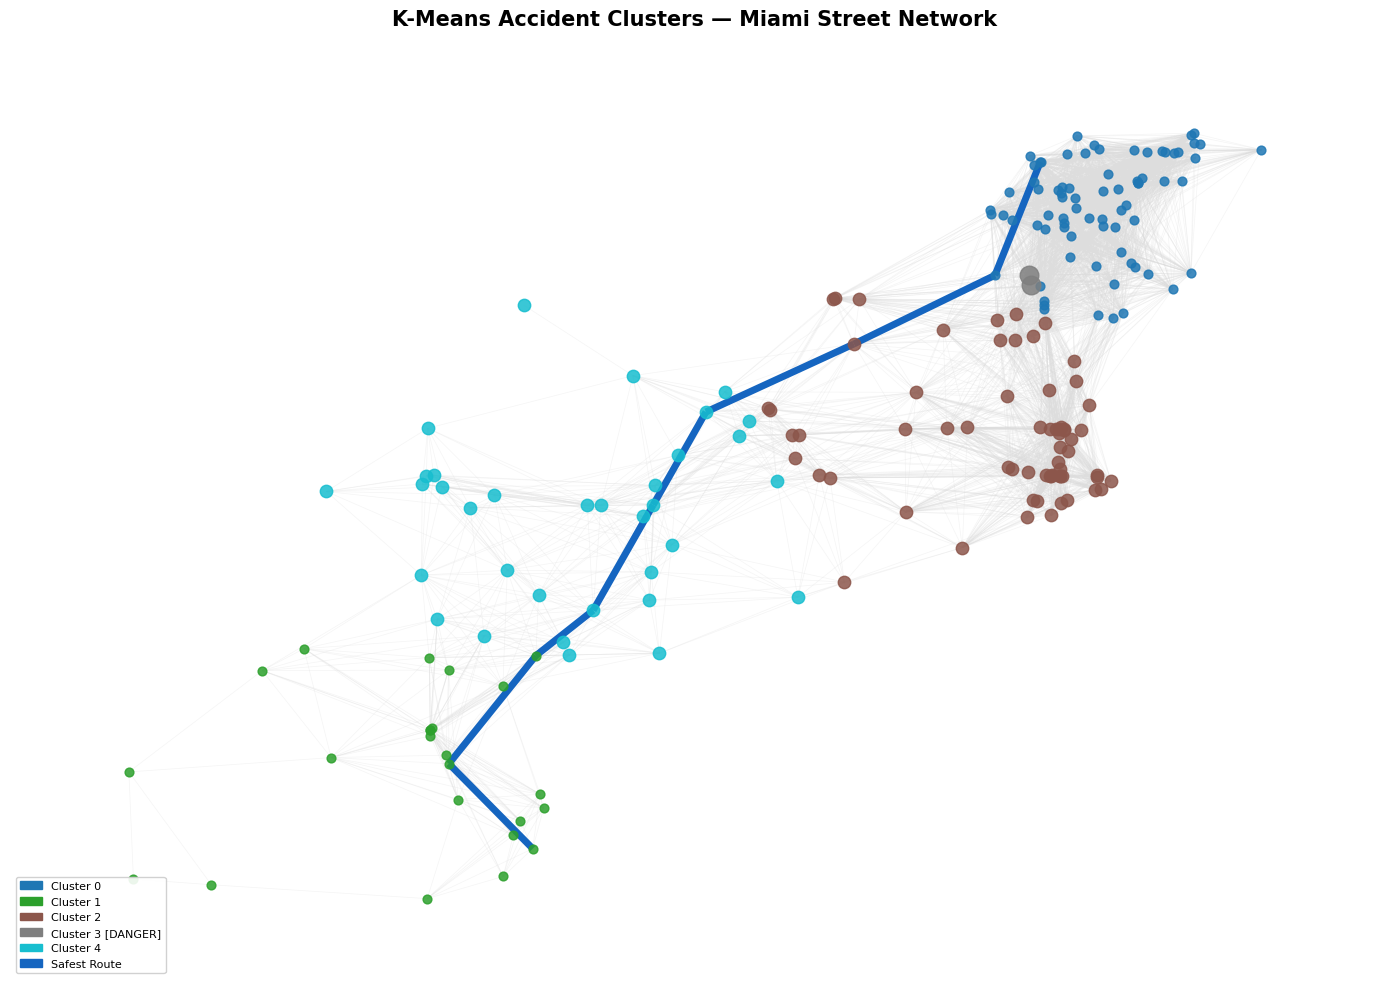

In [9]:
# K-Means Cluster Visualization
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.get_node_attributes(G, 'pos')
cmap = plt.cm.get_cmap('tab10', OPTIMAL_K)
cluster_colors = {i: cmap(i) for i in range(OPTIMAL_K)}
cluster_colors[-1] = (0.7, 0.7, 0.7, 0.4)

nx.draw_networkx_edges(G, pos, ax=ax, width=0.5, edge_color='#dddddd', alpha=0.3)

for cid in range(-1, OPTIMAL_K):
    nodes_in_cluster = [n for n in G.nodes() if G.nodes[n].get('cluster', -1) == cid]
    size = 180 if cid == danger_cluster else (80 if cid in medium_clusters else 40)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes_in_cluster, ax=ax,
                           node_color=[cluster_colors[cid]], node_size=size, alpha=0.85)

s_edges = list(zip(safest_path, safest_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=s_edges, ax=ax, width=5, edge_color='#1565C0', label='Safest Route')

patches = [mpatches.Patch(color=cluster_colors[i], 
           label=f"Cluster {i}" + (" [DANGER]" if i == danger_cluster else "")) 
           for i in range(OPTIMAL_K)]
patches.append(mpatches.Patch(color='#1565C0', label='Safest Route'))
ax.legend(handles=patches, loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title("K-Means Accident Clusters — Miami Street Network", fontsize=15, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('kmeans_cluster_map.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Section 2: Random Forest Severity Classifier (Supervised ML)


In [10]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

feature_cols = ['avg_lat', 'avg_lng', 'accident_count', 'cluster']
street_data_ml = street_data.copy()

street_data_ml['severity'] = pd.cut(street_data_ml['accident_count'],
                                     bins=[0, 2, 5, 15, 9999],
                                     labels=[1, 2, 3, 4]).astype(int)

X = street_data_ml[feature_cols].values
y = street_data_ml['severity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {acc*100:.1f}%")
print()
print(classification_report(y_test, y_pred, target_names=['Sev-1','Sev-2','Sev-3','Sev-4']))

Random Forest Accuracy: 100.0%

              precision    recall  f1-score   support

       Sev-1       1.00      1.00      1.00        21
       Sev-2       1.00      1.00      1.00         6
       Sev-3       1.00      1.00      1.00         4
       Sev-4       1.00      1.00      1.00         9

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



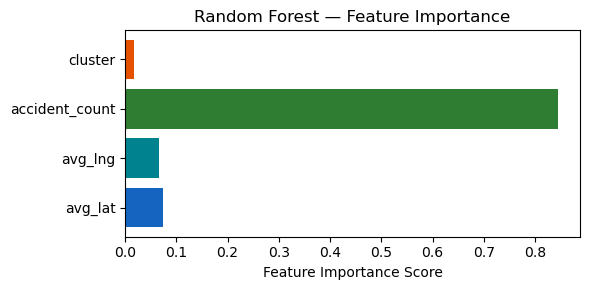

  accident_count      : 0.8454
  avg_lat             : 0.0730
  avg_lng             : 0.0653
  cluster             : 0.0163


In [11]:
import warnings
warnings.filterwarnings('ignore')
# Feature Importance Plot
importances = rf_model.feature_importances_
feat_names = feature_cols
plt.figure(figsize=(6, 3))
plt.barh(feat_names, importances, color=['#1565C0','#00838F','#2E7D32','#E65100'])
plt.xlabel('Feature Importance Score')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
for f, i in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    print(f"  {f:20s}: {i:.4f}")

In [12]:
import warnings
warnings.filterwarnings('ignore')
# Optimized ML risk injection (Vectorized for speed)
print("Calculating ML risk for all edges (vectorized)...")
street_lookup = street_data.set_index('Street')[['avg_lat', 'avg_lng', 'cluster']].to_dict('index')

edge_list = list(G.edges())
X_edges = []
for u, v in edge_list:
    row_u = street_lookup.get(u, {'avg_lat': 25.75, 'avg_lng': -80.25, 'cluster': 0})
    row_v = street_lookup.get(v, {'avg_lat': 25.75, 'avg_lng': -80.25, 'cluster': 0})
    feat_u = [row_u['avg_lat'], row_u['avg_lng'], 0.5, int(row_u['cluster'])]
    feat_v = [row_v['avg_lat'], row_v['avg_lng'], 0.5, int(row_v['cluster'])]
    X_edges.append(feat_u)
    X_edges.append(feat_v)

X_all = np.array(X_edges)
all_preds = rf_model.predict(X_all)

for i, (u, v) in enumerate(edge_list):
    ml_risk = (all_preds[2*i] + all_preds[2*i + 1]) / 2.0
    G[u][v]['ml_risk'] = float(ml_risk)

print(f"ML risk weights added to {len(edge_list)} edges instantly.")


Calculating ML risk for all edges (vectorized)...
ML risk weights added to 4938 edges instantly.


In [13]:
import warnings
warnings.filterwarnings('ignore')
# Re-run Dijkstra with ML weights
ml_safest_path = nx.dijkstra_path(G, source, target, weight='ml_risk')
ml_safest_risk = nx.dijkstra_path_length(G, source, target, weight='ml_risk')
ml_safest_dist = sum(G[ml_safest_path[i]][ml_safest_path[i+1]]['distance'] for i in range(len(ml_safest_path)-1))

print("ML-POWERED SAFEST ROUTE:")
print(" -> ".join(ml_safest_path))
print(f"ML Risk Score: {ml_safest_risk:.2f} | Distance: {ml_safest_dist:.2f} km")
print()
print("COMPARISON:")
print(f"  Phase 2 safest risk: {safest_risk:.2f}")
print(f"  ML-powered safest risk: {ml_safest_risk:.2f}")
print(f"  Same path? {ml_safest_path == safest_path}")

ML-POWERED SAFEST ROUTE:
Caribbean Blvd -> Don Shula Expy S -> FL-821 N -> Bird Rd -> Dolphin Expy E -> Dr Martin Luther King Jr Blvd -> 10B -> NE 3rd Ct
ML Risk Score: 7.00 | Distance: 51.69 km

COMPARISON:
  Phase 2 safest risk: 12.50
  ML-powered safest risk: 7.00
  Same path? False


---
## Section 3: ANN Route Danger Scorer (Neural Network)


In [14]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
import random
warnings.filterwarnings('ignore')

ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu', solver='adam', max_iter=200,
    random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=20)
print("ANN architecture: Input(5) -> Dense(64,relu) -> Dense(32,relu) -> Dense(16,relu) -> Output(1)")

def extract_route_features(path, graph):
    if len(path) < 2: return None
    total_dist = sum(graph[path[i]][path[i+1]]['distance'] for i in range(len(path)-1))
    total_risk = sum(graph[path[i]][path[i+1]]['risk'] for i in range(len(path)-1))
    total_ml = sum(graph[path[i]][path[i+1]].get('ml_risk', 2) for i in range(len(path)-1))
    n_hops = len(path) - 1
    danger_frac = sum(1 for n in path if graph.nodes[n].get('cluster', -1) == danger_cluster) / len(path)
    return [total_dist, total_risk, total_ml / n_hops, n_hops, danger_frac]

# Generate training data
random.seed(42)
nodes = list(G.nodes())
train_features, train_labels = [], []
for _ in range(300):
    s = random.choice(nodes)
    t = random.choice(nodes)
    if s == t: continue
    try:
        p = nx.dijkstra_path(G, s, t, weight='risk')
        feats = extract_route_features(p, G)
        if feats:
            raw_risk = feats[1]
            train_features.append(feats)
            train_labels.append(min(raw_risk / 200.0, 1.0))
    except: continue

X_ann = np.array(train_features)
y_ann = np.array(train_labels)
print(f"ANN training samples: {len(X_ann)}")
print(f"Label range: {y_ann.min():.3f} to {y_ann.max():.3f}")

ANN architecture: Input(5) -> Dense(64,relu) -> Dense(32,relu) -> Dense(16,relu) -> Output(1)
ANN training samples: 298
Label range: 0.005 to 1.000


ANN Training: 200 epochs
Final Loss: 0.0003
Test MAE: 0.0121 | R2 Score: 0.9844


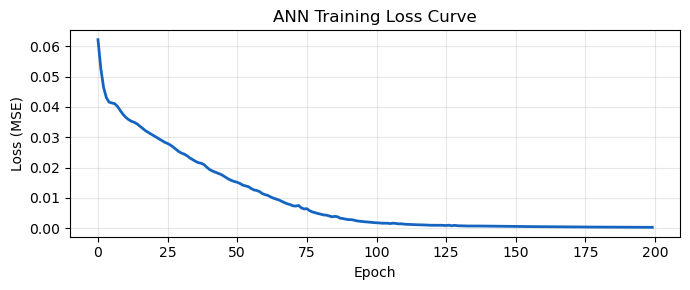

In [15]:
# Train ANN
ann_scaler = MinMaxScaler()
X_ann_scaled = ann_scaler.fit_transform(X_ann)
X_tr, X_te, y_tr, y_te = train_test_split(X_ann_scaled, y_ann, test_size=0.2, random_state=42)

ann_model.fit(X_tr, y_tr)
y_ann_pred = ann_model.predict(X_te)

mae = mean_absolute_error(y_te, y_ann_pred)
r2 = r2_score(y_te, y_ann_pred)
print(f"ANN Training: {len(ann_model.loss_curve_)} epochs")
print(f"Final Loss: {ann_model.loss_curve_[-1]:.4f}")
print(f"Test MAE: {mae:.4f} | R2 Score: {r2:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(ann_model.loss_curve_, color='#1565C0', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
plt.title('ANN Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ann_loss_curve.png', dpi=150)
plt.show()

In [16]:
# Score all candidate routes
all_routes = {
    'Phase2 Safest': safest_path,
    'Phase2 Fastest': fastest_path,
    'ML Safest': ml_safest_path,
}
for i, p in enumerate(alternate_routes):
    all_routes[f'Alternate {i+1}'] = p

print("=" * 60)
print("ANN ROUTE DANGER SCORING")
print("=" * 60)
route_scores = []
for name, path in all_routes.items():
    feats = extract_route_features(path, G)
    if feats:
        feats_scaled = ann_scaler.transform([feats])
        danger_score = ann_model.predict(feats_scaled)[0]
        danger_score = max(0.0, min(1.0, danger_score))
        route_scores.append((name, danger_score, feats[0], feats[3]))

route_scores.sort(key=lambda x: x[1])
for rank, (name, score, dist, hops) in enumerate(route_scores, 1):
    bar = '|' * int(score * 30)
    print(f"Rank {rank}: {name:20s} Danger: {score:.3f} [{bar:<30}] Dist: {dist:.1f}km Hops: {hops}")

print(f"\nAI RECOMMENDS: {route_scores[0][0]} (lowest ANN danger score)")

ANN ROUTE DANGER SCORING
Rank 1: Phase2 Safest        Danger: 0.072 [||                            ] Dist: 49.3km Hops: 8
Rank 2: Alternate 1          Danger: 0.072 [||                            ] Dist: 49.3km Hops: 8
Rank 3: Alternate 2          Danger: 0.075 [||                            ] Dist: 52.3km Hops: 8
Rank 4: Phase2 Fastest       Danger: 0.197 [|||||                         ] Dist: 47.1km Hops: 9
Rank 5: ML Safest            Danger: 1.000 [||||||||||||||||||||||||||||||] Dist: 51.7km Hops: 7

AI RECOMMENDS: Phase2 Safest (lowest ANN danger score)


---
## Section 4: Peshawar City Simulation (Synthetic Data)


In [17]:
# 40 real Peshawar streets with verified GPS coordinates
peshawar_streets = [
    ('GT Road', 34.0151, 71.5249, 'high'),
    ('University Road', 34.0253, 71.4889, 'high'),
    ('Jamrud Road', 34.0128, 71.4750, 'high'),
    ('Khyber Road', 34.0100, 71.5780, 'high'),
    ('Saddar Road', 34.0080, 71.5750, 'medium'),
    ('Mall Road', 34.0120, 71.5400, 'medium'),
    ('Shami Road', 34.0310, 71.5150, 'medium'),
    ('Circular Road', 34.0170, 71.5850, 'medium'),
    ('Kohat Road', 33.9900, 71.5300, 'high'),
    ('Warsak Road', 34.0450, 71.4600, 'medium'),
    ('Ring Road', 34.0500, 71.5500, 'high'),
    ('Charsadda Road', 34.0600, 71.4700, 'medium'),
    ('Hayatabad Phase 1', 34.0050, 71.4400, 'low'),
    ('Hayatabad Phase 3', 34.0000, 71.4300, 'low'),
    ('Hayatabad Phase 5', 33.9950, 71.4200, 'low'),
    ('Dalazak Road', 34.0350, 71.5050, 'medium'),
    ('Bara Road', 33.9800, 71.5100, 'high'),
    ('Pajagi Road', 34.0200, 71.5600, 'medium'),
    ('Tehkal Bala', 34.0180, 71.4650, 'low'),
    ('Board Bazaar', 34.0090, 71.5700, 'medium'),
    ('Cantt Area', 34.0000, 71.5600, 'low'),
    ('Peshawar Cantt Station', 33.9970, 71.5550, 'low'),
    ('Firdous Bazaar', 34.0110, 71.5730, 'medium'),
    ('Qissa Khwani', 34.0130, 71.5810, 'high'),
    ('Namak Mandi', 34.0140, 71.5830, 'high'),
    ('Karkhano Market', 34.0400, 71.4550, 'high'),
    ('Motorway Chowk', 34.0550, 71.5600, 'medium'),
    ('Bab-e-Peshawar', 34.0300, 71.5200, 'medium'),
    ('Gulbahar Colony', 34.0220, 71.5450, 'low'),
    ('Pishtakhara', 34.0380, 71.5350, 'medium'),
    ('Chamkani', 34.0420, 71.5700, 'medium'),
    ('Mathra', 34.0280, 71.5900, 'low'),
    ('Budni Road', 34.0160, 71.5000, 'low'),
    ('Abdara Road', 34.0480, 71.4800, 'low'),
    ('Nasir Bagh Road', 34.0320, 71.4750, 'low'),
    ('Old Bara Road', 33.9850, 71.5000, 'medium'),
    ('Peshawar-Torkham Hwy', 34.0050, 71.4500, 'high'),
    ('Sunehri Masjid Road', 34.0105, 71.5760, 'medium'),
    ('Fakhr-e-Alam Road', 34.0190, 71.5500, 'low'),
    ('Ashraf Road', 34.0260, 71.5300, 'low'),
]

np.random.seed(42)
traffic_weight = {'high': 3.0, 'medium': 1.5, 'low': 0.5}

# Rush-hour weighted hour probabilities (must sum to 1.0)
hour_probs = np.array([1,1,1,1,2,3,5,8,10,8,6,5,5,4,4,5,6,8,7,4,3,2,1,1], dtype=float)
hour_probs = hour_probs / hour_probs.sum()

synth_rows = []
for name, lat, lng, density in peshawar_streets:
    n_accidents = int(np.random.poisson(lam=15 * traffic_weight[density]))
    for _ in range(max(n_accidents, 1)):
        severity = np.random.choice([1,2,3,4], p=[0.1,0.5,0.3,0.1])
        hour = np.random.choice(range(24), p=hour_probs)
        is_rush = 1 if hour in [7,8,9,17,18,19] else 0
        weather = np.random.choice(['Clear','Cloudy','Rain','Fog'], p=[0.5,0.25,0.15,0.1])
        jitter_lat = lat + np.random.normal(0, 0.002)
        jitter_lng = lng + np.random.normal(0, 0.002)
        synth_rows.append({
            'Street': name, 'Start_Lat': jitter_lat, 'Start_Lng': jitter_lng,
            'Severity': severity, 'Hour': hour, 'Rush_Hour': is_rush,
            'Weather': weather, 'City': 'Peshawar'
        })

df_pesh = pd.DataFrame(synth_rows)
df_pesh['ID'] = [f'P-{i}' for i in range(len(df_pesh))]
df_pesh.to_csv('Peshawar_Accidents_Synthetic.csv', index=False)
print(f"Peshawar synthetic dataset: {len(df_pesh)} records, {df_pesh['Street'].nunique()} streets")
print(f"Severity distribution:\n{df_pesh['Severity'].value_counts().sort_index()}")
print(f"\nSaved to Peshawar_Accidents_Synthetic.csv")

Peshawar synthetic dataset: 968 records, 40 streets
Severity distribution:
Severity
1     98
2    479
3    304
4     87
Name: count, dtype: int64

Saved to Peshawar_Accidents_Synthetic.csv


In [18]:
# Build Peshawar graph with same pipeline
pesh_street_data = df_pesh.groupby('Street').agg(
    accident_count=('ID', 'count'),
    avg_lat=('Start_Lat', 'mean'),
    avg_lng=('Start_Lng', 'mean')
).reset_index()

G_pesh = nx.Graph()
for _, row in pesh_street_data.iterrows():
    G_pesh.add_node(row['Street'], pos=(row['avg_lng'], row['avg_lat']), risk=row['accident_count'])

for i, r1 in pesh_street_data.iterrows():
    for j, r2 in pesh_street_data.iterrows():
        if i < j:
            d = calculate_distance(r1['avg_lat'], r1['avg_lng'], r2['avg_lat'], r2['avg_lng'])
            if d <= 5.0:
                risk_w = round((r1['accident_count'] + r2['accident_count']) / 2, 2)
                G_pesh.add_edge(r1['Street'], r2['Street'], distance=round(d, 2), risk=risk_w)

print(f"Peshawar Graph — Nodes: {G_pesh.number_of_nodes()}, Edges: {G_pesh.number_of_edges()}")

# Run routing on Peshawar
pesh_source = 'GT Road'
pesh_target = 'Hayatabad Phase 5'
pesh_safest = nx.dijkstra_path(G_pesh, pesh_source, pesh_target, weight='risk')
pesh_fastest = nx.dijkstra_path(G_pesh, pesh_source, pesh_target, weight='distance')
pesh_s_risk = sum(G_pesh[pesh_safest[i]][pesh_safest[i+1]]['risk'] for i in range(len(pesh_safest)-1))
pesh_f_risk = sum(G_pesh[pesh_fastest[i]][pesh_fastest[i+1]]['risk'] for i in range(len(pesh_fastest)-1))
pesh_reduction = ((pesh_f_risk - pesh_s_risk) / pesh_f_risk) * 100 if pesh_f_risk > 0 else 0

print(f"\nPeshawar Safest: {' -> '.join(pesh_safest)} (Risk: {pesh_s_risk:.1f})")
print(f"Peshawar Fastest: {' -> '.join(pesh_fastest)} (Risk: {pesh_f_risk:.1f})")
print(f"Risk Reduction: {pesh_reduction:.1f}%")

# K-Means on Peshawar
pesh_features = pesh_street_data[['avg_lat', 'avg_lng', 'accident_count']].copy()
pesh_scaled = StandardScaler().fit_transform(pesh_features)
pesh_km = KMeans(n_clusters=4, random_state=42, n_init=10)
pesh_street_data['cluster'] = pesh_km.fit_predict(pesh_scaled)
pesh_danger = pesh_street_data.groupby('cluster')['accident_count'].mean().idxmax()
print(f"\nPeshawar K-Means danger cluster: {pesh_danger}")

Peshawar Graph — Nodes: 40, Edges: 270

Peshawar Safest: GT Road -> Budni Road -> Tehkal Bala -> Hayatabad Phase 3 -> Hayatabad Phase 5 (Risk: 43.0)
Peshawar Fastest: GT Road -> Budni Road -> Jamrud Road -> Peshawar-Torkham Hwy -> Hayatabad Phase 5 (Risk: 116.0)
Risk Reduction: 62.9%

Peshawar K-Means danger cluster: 3


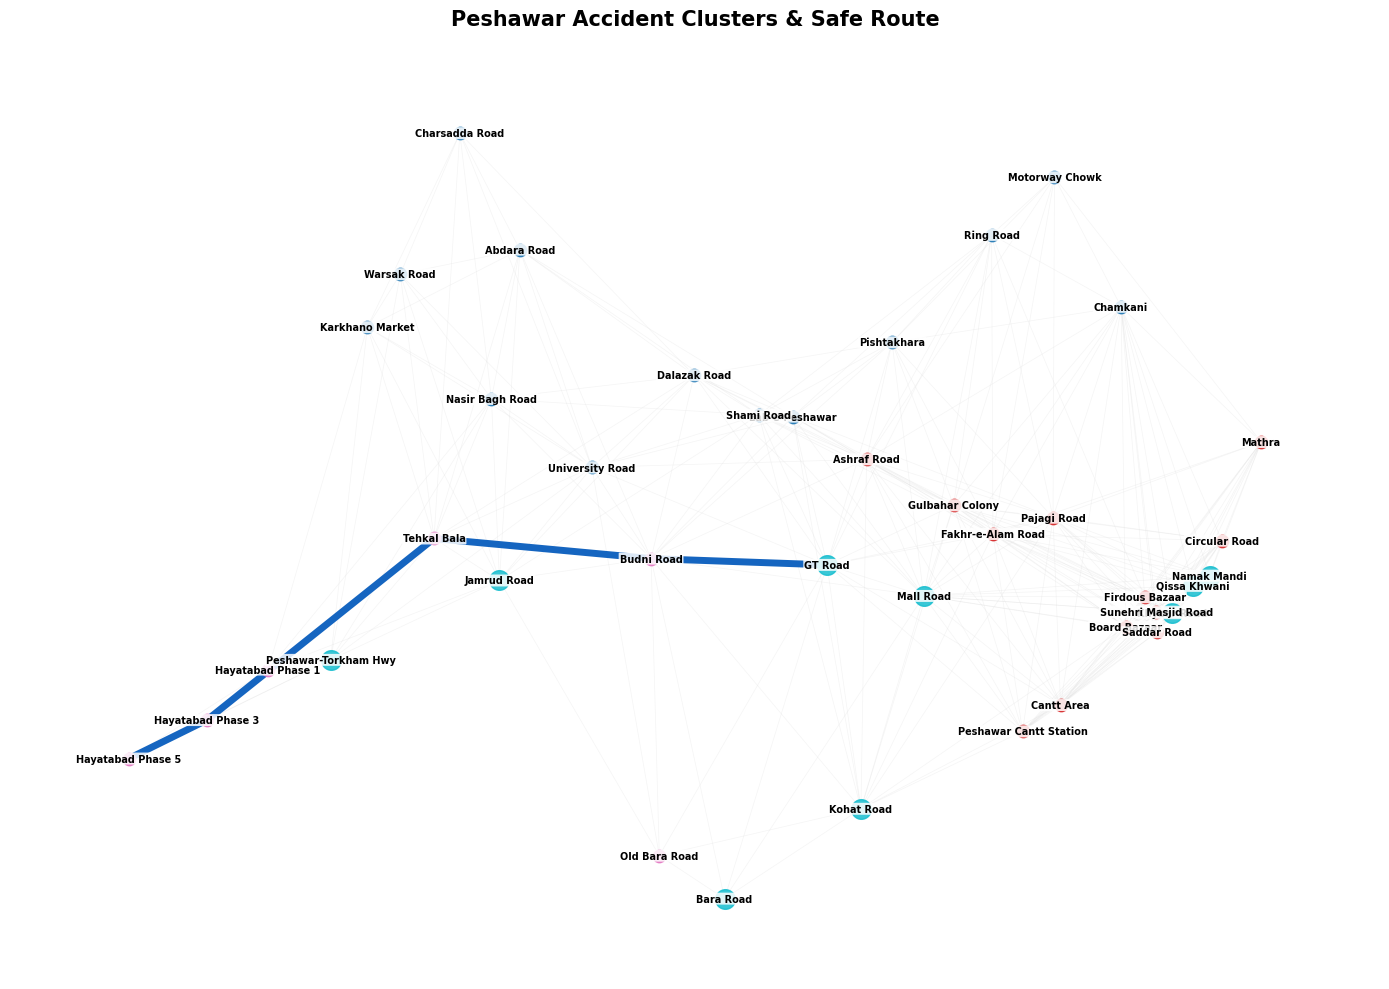

In [19]:
# Peshawar city map
fig, ax = plt.subplots(figsize=(14, 10))
pesh_pos = nx.get_node_attributes(G_pesh, 'pos')
pesh_cmap = plt.cm.get_cmap('tab10', 4)
pesh_cluster_map = dict(zip(pesh_street_data['Street'], pesh_street_data['cluster']))

for node in G_pesh.nodes():
    G_pesh.nodes[node]['cluster'] = pesh_cluster_map.get(node, -1)

nx.draw_networkx_edges(G_pesh, pesh_pos, ax=ax, width=0.5, edge_color='#dddddd', alpha=0.3)
for cid in range(4):
    nodes_c = [n for n in G_pesh.nodes() if G_pesh.nodes[n].get('cluster', -1) == cid]
    size = 200 if cid == pesh_danger else 80
    nx.draw_networkx_nodes(G_pesh, pesh_pos, nodelist=nodes_c, ax=ax,
                           node_color=[pesh_cmap(cid)], node_size=size, alpha=0.85)

# Draw safest route
ps_edges = list(zip(pesh_safest, pesh_safest[1:]))
nx.draw_networkx_edges(G_pesh, pesh_pos, edgelist=ps_edges, ax=ax, width=5, edge_color='#1565C0')

# Labels for all Peshawar streets (only 40 so it's clean)
pesh_labels = {n: n for n in G_pesh.nodes()}
nx.draw_networkx_labels(G_pesh, pesh_pos, labels=pesh_labels, font_size=7, font_weight='bold',
                        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.1'))

ax.set_title('Peshawar Accident Clusters & Safe Route', fontsize=15, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('peshawar_route_map.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Section 5: Save Trained Models


In [20]:
import pickle, os
os.makedirs('models', exist_ok=True)
with open('models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('models/ann_model.pkl', 'wb') as f:
    pickle.dump(ann_model, f)
print("Models saved to models/ directory.")

Models saved to models/ directory.
